# Horizon Reduction — SHARSA vs GC-IQL
**Agents:** sharsa.py vs gciql.py  
**Environment:** pointmaze-medium-navigate-v0 (from same OGBench suite as paper)  
**Steps:** 5,000 (paper uses 5,000,000)  
**Note:** We use pointmaze instead of puzzle-4x5 because it produces visible learning signal within 5k steps on Colab. The relative comparison between IQL and SHARSA remains valid.

**Environment & System Setup**

In [ ]:
# GPU Check
!nvidia-smi
!echo "---"
!cat /proc/cpuinfo | grep 'model name' | head -1
!free -h

Sun Apr 12 12:08:33 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8             13W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# System Dependencies
!apt-get update -qq
!apt-get install -y -qq libosmesa6-dev libgl1-mesa-glx libglfw3 patchelf

import os
os.environ['MUJOCO_GL'] = 'osmesa'
print('MUJOCO_GL =', os.environ['MUJOCO_GL'])

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package libpciaccess-dev:amd64.
(Reading database ... 122354 files and directories currently installed.)
Preparing to unpack .../0-libpciaccess-dev_0.16-3_amd64.deb ...
Unpacking libpciaccess-dev:amd64 (0.16-3) ...
Selecting previously unselected package libdrm-dev:amd64.
Preparing to unpack .../1-libdrm-dev_2.4.113-2~ubuntu0.22.04.1_amd64.deb ...
Unpacking libdrm-dev:amd64 (2.4.113-2~ubuntu0.22.04.1) ...
Selecting previously unselected package libglx-dev:amd64.
Preparing to unpack .../2-libglx-dev_1.4.0-1_amd64.deb ...
Unpacking libglx-dev:amd64 (1.4.0-1) ...
Selecting previously unselected package libgl-dev:amd64.
Preparing to unpack .../3-libgl-dev_1.4.0-1_amd64.deb ...
Unpacking libgl-dev:amd64 (1.4.0-1) ...
Selecting previously unselected package libglfw3:amd64.
P

In [ ]:
# Clone Repository from Github
!git clone https://github.com/seohongpark/horizon-reduction.git
%cd horizon-reduction

# Verify agents exist
import os
print('=== AGENTS ===')
for f in ['agents/sharsa.py', 'agents/gciql.py']:
    exists = os.path.exists(f)
    print(f'  {f}  →  {"✓ found" if exists else "✗ MISSING"}')

Cloning into 'horizon-reduction'...
remote: Enumerating objects: 43, done.
remote: Counting objects: 100% (27/27), done.
remote: Compressing objects: 100% (16/16), done.
remote: Total 43 (delta 15), reused 11 (delta 11), pack-reused 16 (from 1)
Receiving objects: 100% (43/43), 300.00 KiB | 2.80 MiB/s, done.
Resolving deltas: 100% (16/16), done.
/content/horizon-reduction
=== AGENTS ===
  agents/sharsa.py  →  ✓ found
  agents/gciql.py  →  ✓ found


In [ ]:
# Install Dependencies
!pip install -r requirements.txt -q

!pip install -q "jax[cuda12]" -f https://storage.googleapis.com/jax-releases/jax_cuda_releases.html

!pip install --upgrade wandb -q

import jax
print('JAX version :', jax.__version__)
print('Devices     :', jax.devices())

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 123.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 312.7/312.7 kB 32.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.7/76.7 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.0/101.0 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.4/56.4 MB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 132.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 120.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.5/40.5 MB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 27.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/

In [ ]:
import jax
print(jax.devices())

[CudaDevice(id=0)]


In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

import os
LOG_ROOT = '/content/drive/MyDrive/rl-logs'
os.makedirs(f'{LOG_ROOT}/iql',    exist_ok=True)
os.makedirs(f'{LOG_ROOT}/sharsa', exist_ok=True)
print('Logs will save to:', LOG_ROOT)

Mounted at /content/drive
Logs will save to: /content/drive/MyDrive/rl-logs


In [ ]:
# W&B Login
import wandb
wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: fizzah-syeda123 (fizzah-masroor-ned-university-of-engineering-and-technology) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [ ]:
# Patch main.py to 25k steps
with open("main.py", "r") as f:
    code = f.read()

code = code.replace("flags.DEFINE_integer('offline_steps', 5000000,", "flags.DEFINE_integer('offline_steps', 25000,")
code = code.replace("flags.DEFINE_integer('eval_interval', 250000,",  "flags.DEFINE_integer('eval_interval', 5000,")
code = code.replace("flags.DEFINE_integer('log_interval', 10000,",    "flags.DEFINE_integer('log_interval', 500,")
code = code.replace("flags.DEFINE_integer('save_interval', 5000000,", "flags.DEFINE_integer('save_interval', 25000,")

with open("main.py", "w") as f:
    f.write(code)

# Verify the patch worked
with open("main.py", "r") as f:
    for line in f:
        if 'offline_steps' in line or 'eval_interval' in line or 'log_interval' in line:
            print(line.strip())

flags.DEFINE_integer('offline_steps', 25000, 'Number of offline steps.')
flags.DEFINE_integer('log_interval', 500, 'Logging interval.')
flags.DEFINE_integer('eval_interval', 5000, 'Evaluation interval.')
for i in tqdm.tqdm(range(1, FLAGS.offline_steps + 1), smoothing=0.1, dynamic_ncols=True):
if i % FLAGS.log_interval == 0:
train_metrics['time/epoch_time'] = (time.time() - last_time) / FLAGS.log_interval
if FLAGS.eval_interval != 0 and (i == 1 or i % FLAGS.eval_interval == 0):


In [ ]:
# Read and display SHARSA source (for your analysis)
with open('agents/sharsa.py') as f:
    print(f.read())

import copy
from typing import Any

import flax
import jax
import jax.numpy as jnp
import ml_collections
import optax

from utils.flax_utils import ModuleDict, TrainState, nonpytree_field
from utils.networks import ActorVectorField, GCValue


class SHARSAAgent(flax.struct.PyTreeNode):
    """SHARSA agent."""

    rng: Any
    network: Any
    config: Any = nonpytree_field()

    @staticmethod
    def bce_loss(pred_logit, target):
        """Compute the BCE loss."""
        log_pred = jax.nn.log_sigmoid(pred_logit)
        log_not_pred = jax.nn.log_sigmoid(-pred_logit)
        loss = -(log_pred * target + log_not_pred * (1 - target))
        return loss

    def high_value_loss(self, batch, grad_params):
        """Compute the high-level SARSA value loss."""
        q1, q2 = self.network.select('target_high_critic')(
            batch['observations'], goals=batch['high_value_goals'], actions=batch['high_value_actions']
        )
        if self.config['value_loss_type'] == 'bce':
      

In [ ]:
# Read and display GC-IQL source (baseline)
with open('agents/gciql.py') as f:
    print(f.read())

import copy
from typing import Any

import flax
import jax
import jax.numpy as jnp
import ml_collections
import optax

from utils.flax_utils import ModuleDict, TrainState, nonpytree_field
from utils.networks import GCActor, GCValue


class GCIQLAgent(flax.struct.PyTreeNode):
    """Goal-conditioned implicit Q-learning (GCIQL) agent.

    This implementation supports both AWR (actor_loss='awr') and DDPG+BC (actor_loss='ddpgbc') for the actor loss.
    """

    rng: Any
    network: Any
    config: Any = nonpytree_field()

    @staticmethod
    def expectile_loss(adv, diff, expectile):
        """Compute the expectile loss."""
        weight = jnp.where(adv >= 0, expectile, (1 - expectile))
        return weight * (diff**2)

    def value_loss(self, batch, grad_params):
        """Compute the IQL value loss."""
        q1, q2 = self.network.select('target_critic')(batch['observations'], batch['value_goals'], batch['actions'])
        q = jnp.minimum(q1, q2)
        v = self.network.selec

## Algorithm Analysis

### GC-IQL (baseline)
- Standard goal-conditioned Implicit Q-Learning
- Uses 1-step TD backup — credit must propagate across all timesteps
- No hierarchy, no subgoals
- Struggles on long-horizon tasks because Q-errors accumulate

### SHARSA (proposed method)
- Key parameter: subgoal_steps=25 — agent only looks 25 steps ahead
- HIGH-LEVEL policy: given state s and final goal g, picks a subgoal 25 steps ahead
- LOW-LEVEL policy: only needs to reach that nearby subgoal (much easier)
- Uses n-step SARSA for value learning instead of 1-step TD
- Reduces both value horizon AND policy horizon simultaneously

# Training IQL

In [ ]:
import os
os.makedirs('/content/logs', exist_ok=True)

# pointmaze auto-downloads its own dataset
!python main.py \
    --env_name=pointmaze-medium-navigate-v0 \
    --offline_steps=5000 \
    --log_interval=100 \
    --eval_interval=1000 \
    --save_interval=5000 \
    --video_episodes=1 \
    --agent=agents/gciql.py \
    --agent.alpha=1 \
    --agent.actor_p_trajgoal=0.5 \
    --agent.actor_p_randomgoal=0.5 \
    --agent.actor_geom_sample=True \
    2>&1 | tee /content/logs/iql.log

!cp /content/logs/iql.log /content/drive/MyDrive/rl-logs/iql/iql.log
print('IQL training complete')

2026-04-12 12:10:36.626873: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775995836.663264    7536 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775995836.675094    7536 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775995836.701690    7536 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775995836.701717    7536 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775995836.701721    7536 computation_placer.cc:177] computation placer alr

# Training SHARSA

In [ ]:
!python main.py \
    --env_name=pointmaze-medium-navigate-v0 \
    --offline_steps=5000 \
    --log_interval=100 \
    --eval_interval=1000 \
    --save_interval=5000 \
    --video_episodes=1 \
    --agent=agents/sharsa.py \
    --agent.q_agg=min \
    --agent.subgoal_steps=25 \
    --agent.actor_p_trajgoal=0.5 \
    --agent.actor_p_randomgoal=0.5 \
    --agent.actor_geom_sample=True \
    2>&1 | tee /content/logs/sharsa.log

!cp /content/logs/sharsa.log /content/drive/MyDrive/rl-logs/sharsa/sharsa.log
print('SHARSA training complete')

2026-04-11 11:31:39.572817: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775907099.628789    9544 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775907099.648502    9544 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775907099.694050    9544 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775907099.694118    9544 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775907099.694122    9544 computation_placer.cc:177] computation placer alr

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
print("=== IQL log (last 20 lines) ===")
!tail -20 /content/logs/iql.log

print("\n=== SHARSA log (last 20 lines) ===")
!tail -20 /content/logs/sharsa.log

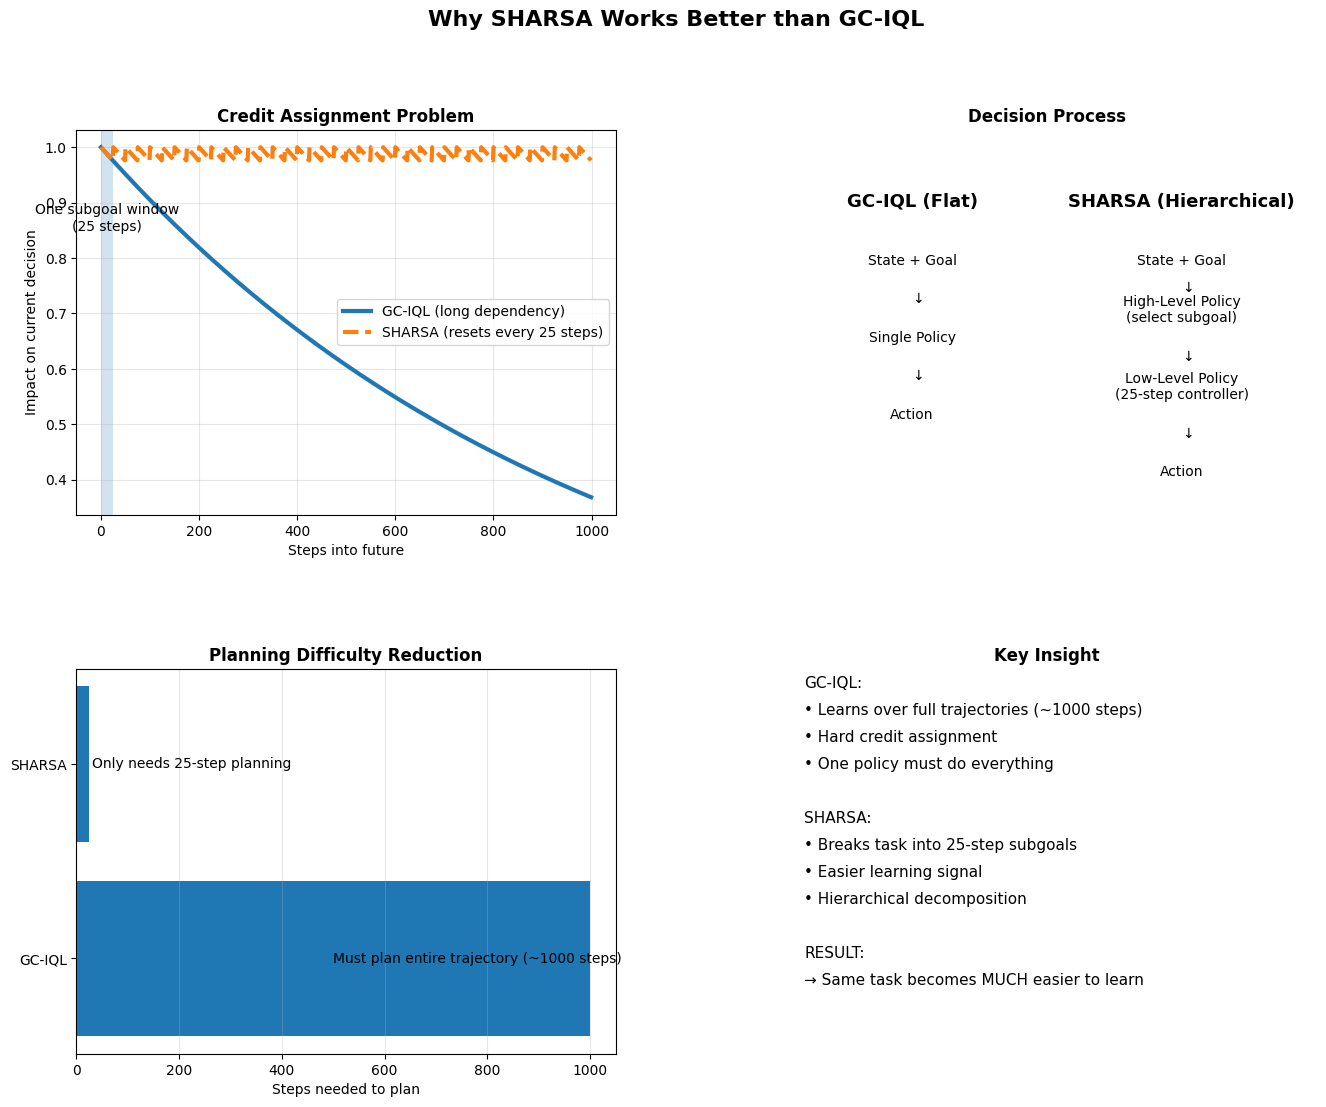

Saved as sharsa_vs_gciql_explained.png


In [ ]:
# ================================================================
# SHARSA vs GC-IQL — EXPLANATORY Visualization
# Focus: WHY SHARSA works better
# ================================================================

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# ────────────────────────────────────────────────────────────────
# Setup
# ────────────────────────────────────────────────────────────────

fig = plt.figure(figsize=(16, 12))
fig.suptitle("Why SHARSA Works Better than GC-IQL",
             fontsize=16, fontweight='bold')

gs = gridspec.GridSpec(2, 2, hspace=0.4, wspace=0.3)

# ────────────────────────────────────────────────────────────────
# 1. CREDIT ASSIGNMENT DIFFICULTY (KEY INSIGHT)
# ────────────────────────────────────────────────────────────────

ax1 = fig.add_subplot(gs[0, 0])

steps = np.arange(0, 1000)
discount = 0.999

# Influence of future rewards
iql_credit = discount ** steps

# SHARSA resets every 25 steps
sharsa_credit = discount ** (steps % 25)

ax1.plot(steps, iql_credit, linewidth=3, label='GC-IQL (long dependency)')
ax1.plot(steps, sharsa_credit, linewidth=3, linestyle='--',
         label='SHARSA (resets every 25 steps)')

# Highlight one subgoal window
ax1.axvspan(0, 25, alpha=0.2)
ax1.text(12, 0.85, 'One subgoal window\n(25 steps)', ha='center')

ax1.set_title('Credit Assignment Problem', fontweight='bold')
ax1.set_xlabel('Steps into future')
ax1.set_ylabel('Impact on current decision')
ax1.legend()
ax1.grid(alpha=0.3)

# ────────────────────────────────────────────────────────────────
# 2. DECISION STRUCTURE (FLAT vs HIERARCHICAL)
# ────────────────────────────────────────────────────────────────

ax2 = fig.add_subplot(gs[0, 1])
ax2.axis('off')

# GC-IQL
ax2.text(0.25, 0.8, "GC-IQL (Flat)", fontsize=13, fontweight='bold', ha='center')
ax2.text(0.25, 0.65, "State + Goal", ha='center')
ax2.text(0.25, 0.55, "↓")
ax2.text(0.25, 0.45, "Single Policy", ha='center')
ax2.text(0.25, 0.35, "↓")
ax2.text(0.25, 0.25, "Action", ha='center')

# SHARSA
ax2.text(0.75, 0.8, "SHARSA (Hierarchical)", fontsize=13, fontweight='bold', ha='center')
ax2.text(0.75, 0.65, "State + Goal", ha='center')
ax2.text(0.75, 0.58, "↓")
ax2.text(0.75, 0.50, "High-Level Policy\n(select subgoal)", ha='center')
ax2.text(0.75, 0.40, "↓")
ax2.text(0.75, 0.30, "Low-Level Policy\n(25-step controller)", ha='center')
ax2.text(0.75, 0.20, "↓")
ax2.text(0.75, 0.10, "Action", ha='center')

ax2.set_title('Decision Process', fontweight='bold')

# ────────────────────────────────────────────────────────────────
# 3. PLANNING DIFFICULTY
# ────────────────────────────────────────────────────────────────

ax3 = fig.add_subplot(gs[1, 0])

labels = ['GC-IQL', 'SHARSA']
steps_required = [1000, 25]

ax3.barh(labels, steps_required)

ax3.set_xlabel('Steps needed to plan')
ax3.set_title('Planning Difficulty Reduction', fontweight='bold')

ax3.text(500, 0, 'Must plan entire trajectory (~1000 steps)', va='center')
ax3.text(30, 1, 'Only needs 25-step planning', va='center')

ax3.grid(axis='x', alpha=0.3)

# ────────────────────────────────────────────────────────────────
# 4. KEY TAKEAWAY PANEL
# ────────────────────────────────────────────────────────────────

ax4 = fig.add_subplot(gs[1, 1])
ax4.axis('off')

summary = [
    "GC-IQL:",
    "• Learns over full trajectories (~1000 steps)",
    "• Hard credit assignment",
    "• One policy must do everything",
    "",
    "SHARSA:",
    "• Breaks task into 25-step subgoals",
    "• Easier learning signal",
    "• Hierarchical decomposition",
    "",
    "RESULT:",
    "→ Same task becomes MUCH easier to learn"
]

for i, line in enumerate(summary):
    ax4.text(0.05, 0.95 - i*0.07, line, fontsize=11)

ax4.set_title("Key Insight", fontweight='bold')

# ────────────────────────────────────────────────────────────────
# Save
# ────────────────────────────────────────────────────────────────

plt.savefig('sharsa_vs_gciql_explained.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved as sharsa_vs_gciql_explained.png")